<a href="https://colab.research.google.com/github/asianman940121-crypto/-/blob/main/%E5%85%83%E5%95%9F%E7%99%BC%E6%BC%94%E7%AE%97%E6%B3%95%E8%A9%A6%E5%81%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random Optimization
基本的隨機最佳化演算法(Primitive RO) :: 步驟

In [ ]:
import numpy as np

# 定義我們要尋找谷底的函數 (碗狀函數)
def f(x):
    return np.sum(x**2)

# === Step 1: 初始化 ===
dim = 2 # 我們在 2 維平面上尋找
x = np.random.uniform(-5, 5, dim) # 隨機空投一個起點 (範圍 -5 到 5)
current_f = f(x)                  # 測量起點的高度
sigma = 0.5                       # 設定步伐大小 (常態分佈的標準差)

max_iter = 50 # === Step 4: 終止條件 (走 50 步就停) ===

print(f"空投起點: {x}, 初始高度: {current_f:.4f}\n")

for i in range(max_iter):
    # === Step 2: 隨機探勘 ===
    dx = np.random.normal(0, sigma, dim) # 根據常態分佈隨機產生一步
    new_x = x + dx                       # 計算試探的新位置
    new_f = f(new_x)                     # 測量新位置的高度

    # === Step 3: 貪婪更新 ===
    if new_f < current_f: # 如果新位置比較低 (更好)
        x = new_x         # 移動過去！
        current_f = new_f # 更新目前最低高度
        print(f"第 {i+1} 步: 找到更低點！移至 {x}, 高度降為 {current_f:.4f}")

print(f"\n尋寶結束！最終位置: {x}, 最終高度: {current_f:.4f}")

空投起點: [-4.79595512 -3.42832797], 初始高度: 34.7546

第 1 步: 找到更低點！移至 [-3.81209647 -3.22120772], 高度降為 24.9083
第 3 步: 找到更低點！移至 [-3.79542169 -2.86003761], 高度降為 22.5850
第 5 步: 找到更低點！移至 [-3.66746804 -2.06087215], 高度降為 17.6975
第 6 步: 找到更低點！移至 [-3.43466453 -2.12292216], 高度降為 16.3037
第 9 步: 找到更低點！移至 [-3.4320972  -2.02654804], 高度降為 15.8862
第 10 步: 找到更低點！移至 [-3.51482308 -1.72302986], 高度降為 15.3228
第 11 步: 找到更低點！移至 [-3.33040358 -1.26957668], 高度降為 12.7034
第 17 步: 找到更低點！移至 [-3.18761426 -1.55339479], 高度降為 12.5739
第 19 步: 找到更低點！移至 [-2.85146667 -1.94474351], 高度降為 11.9129
第 20 步: 找到更低點！移至 [-2.81715272 -1.75841282], 高度降為 11.0284
第 22 步: 找到更低點！移至 [-3.07778003 -0.87703991], 高度降為 10.2419
第 24 步: 找到更低點！移至 [-2.26645303 -0.51680093], 高度降為 5.4039
第 25 步: 找到更低點！移至 [-1.7305112  -0.40537222], 高度降為 3.1590
第 26 步: 找到更低點！移至 [-0.95970671 -1.03272893], 高度降為 1.9876
第 27 步: 找到更低點！移至 [-0.45906203 -1.19090087], 高度降為 1.6290
第 30 步: 找到更低點！移至 [-0.81739346 -0.51299821], 高度降為 0.9313
第 31 步: 找到更低點！移至 [-0.41956683 -0.33447397], 高度降為 0

改良式隨機最佳化演算法(Improved RO) :: 步驟

In [ ]:
import numpy as np

# 定義要尋找谷底的損失函數 (碗狀函數)
def f(x):
    return np.sum(x**2)

# === Step 1: 初始化 ===
dim = 2
x = np.random.uniform(-5, 5, dim) # 隨機初始位置
b = np.zeros(dim)                 # 初始化偏置項 (慣性) 為 0
current_f = f(x)
sigma = 0.5                       # 常態分佈標準差
max_iter = 50

print(f"空投起點: {x}, 初始高度: {current_f:.4f}\n")

for i in range(max_iter):
    # === Step 2: 產生隨機向量 ===
    dx = np.random.normal(0, sigma, dim)

    # 準備「往前走」的位置
    new_x_forward = x + b + dx
    f_forward = f(new_x_forward)

    # === Step 3: 往前走測試 ===
    if f_forward < current_f:
        x = new_x_forward               # 移動到新位置
        current_f = f_forward
        b = 0.2 * b + 0.4 * dx          # 增強該方向的慣性
        print(f"第 {i+1} 步 [往前]: 移至 {x}, 高度降為 {current_f:.4f}")

    else:
        # === Step 4: 往後退測試 (反向探勘) ===
        new_x_reverse = x + b - dx
        f_reverse = f(new_x_reverse)

        if f_reverse < current_f:
            x = new_x_reverse           # 移動到反方向的新位置
            current_f = f_reverse
            b = b - 0.4 * dx            # 修正慣性方向
            print(f"第 {i+1} 步 [往後]: 移至 {x}, 高度降為 {current_f:.4f}")

        else:
            # === Step 5: 碰壁減速 ===
            b = 0.5 * b                 # 慣性減半
            # 注意：此時 x 不變，留在原地

# === Step 6: 達到最大迭代次數，終止 ===
print(f"\n尋寶結束！最終位置: {x}, 最終高度: {current_f:.4f}")

空投起點: [-0.94132426 -4.40719355], 初始高度: 20.3094

第 1 步 [往後]: 移至 [-0.20355492 -3.38147187], 高度降為 11.4758
第 2 步 [往前]: 移至 [ 0.58701684 -2.99739877], 高度降為 9.3290
第 3 步 [往後]: 移至 [ 0.42384052 -2.40161397], 高度降為 5.9474
第 4 步 [往前]: 移至 [ 0.12597149 -1.51581402], 高度降為 2.3136
第 5 步 [往後]: 移至 [ 0.77344649 -0.98326521], 高度降為 1.5650
第 6 步 [往前]: 移至 [ 0.68645221 -0.74280526], 高度降為 1.0230
第 7 步 [往後]: 移至 [ 0.70495152 -0.51305994], 高度降為 0.7602
第 8 步 [往前]: 移至 [ 0.16341959 -0.23786644], 高度降為 0.0833
第 9 步 [往後]: 移至 [-0.26821526 -0.06260512], 高度降為 0.0759
第 10 步 [往前]: 移至 [-0.19671322 -0.1122289 ], 高度降為 0.0513
第 11 步 [往後]: 移至 [0.15292918 0.03490311], 高度降為 0.0246

尋寶結束！最終位置: [0.15292918 0.03490311], 最終高度: 0.0246


PSO 的基本迴圈架構

In [ ]:
import numpy as np

# 定義要最佳化的損失函數 (以簡單的碗狀函數為例，最佳解在 0,0)
def f(x):
    return np.sum(x**2)

# ==========================================
# 依據 P.12-13 架構設定 PSO 參數
# ==========================================
D = 2               # 搜索空間維度 (D)
n_swarm = 20        # 粒子數量 (n_swarm)
max_iter = 50       # 最大迭代次數 (Step 3 停止條件)

# P.13 的控制參數約束
omega = 0.7         # 慣性權重 (omega_d)：必須小於 1 以防止搜尋爆炸
c_p = 2.0           # 自我認知參數乘數：依據 P.13 建議，常設於 [1, 3] 區間
c_g = 2.0           # 群體認知參數乘數：依據 P.13 建議，常設於 [1, 3] 區間

# 搜尋空間與速度的上下限
x_min, x_max = -5.0, 5.0
v_min, v_max = -1.0, 1.0

# ==========================================
# Step 1: 初始化
# ==========================================
gBest = None
gBest_score = float('inf')

# 預先建立儲存群體狀態的矩陣
X = np.zeros((n_swarm, D))
V = np.zeros((n_swarm, D))
pBest = np.zeros((n_swarm, D))
pBest_score = np.full(n_swarm, float('inf'))

# 執行迴圈 i = 1, 2, ..., n_swarm [初始化之粒子迴圈]
for i in range(n_swarm):
    # 使用均勻分佈的隨機向量初始化粒子位置
    X[i] = np.random.uniform(x_min, x_max, D)

    # 將粒子 i 的 pBest 位置初始化為初始位置
    pBest[i] = np.copy(X[i])
    score = f(pBest[i])
    pBest_score[i] = score

    # 若 f(pBest_i) < f(gBest)，則更新 gBest
    if score < gBest_score:
        gBest = np.copy(pBest[i])
        gBest_score = score

    # 初始化粒子 i 的速度向量
    V[i] = np.random.uniform(v_min, v_max, D)


# ==========================================
# Step 2 & Step 3: 粒子迴圈與終止條件
# ==========================================
for k in range(max_iter): # Step 3: 檢查停止條件

    # 執行迴圈 i = 1, 2, ..., n_swarm [粒子迴圈]
    for i in range(n_swarm):

        # 執行迴圈 d = 1, 2, ..., D [搜索空間維度迴圈]
        for d in range(D):
            # 選擇維度 d 之隨機亂數於均勻分佈區間 [0,1]
            r_p = np.random.rand()
            r_g = np.random.rand()

            # 結合 P.13 的參數，計算最終的認知係數 xi_p 與 xi_g
            xi_p = c_p * r_p
            xi_g = c_g * r_g

            # 更新粒子 i 之維度 d 的速度 (對應 P.11 式 1)
            V[i, d] = omega * V[i, d] + xi_p * (pBest[i, d] - X[i, d]) + xi_g * (gBest[d] - X[i, d])

        # [得到粒子 i 之速度向量更新完畢]

        # 更新粒子 i 之位置向量 (對應 P.11 式 2)
        X[i] = X[i] + V[i]

        # 評估新位置的損失函數值
        current_score = f(X[i])

        # 若 f(Xi) < f(pBest_i)，則 pBest_i <- Xi
        if current_score < pBest_score[i]:
            pBest[i] = np.copy(X[i])
            pBest_score[i] = current_score

        # 若 f(pBest_i) < f(gBest)，則 gBest <- pBest_i
        if pBest_score[i] < gBest_score:
            gBest = np.copy(pBest[i])
            gBest_score = pBest_score[i]

    # 每 10 個迭代印出一次目前成果
    if (k + 1) % 10 == 0:
        print(f"迭代 {k+1}: 全村最佳位置 = {gBest}, 分數 = {gBest_score:.6f}")

print(f"\n最佳化結束！")
print(f"最終找到的極值座標: {gBest}, 完美趨近於 0")

迭代 10: 全村最佳位置 = [ 0.10638958 -0.09322015], 分數 = 0.020009
迭代 20: 全村最佳位置 = [-0.0791201  -0.05321428], 分數 = 0.009092
迭代 30: 全村最佳位置 = [ 0.00125788 -0.02057724], 分數 = 0.000425
迭代 40: 全村最佳位置 = [ 0.0002762  -0.00216677], 分數 = 0.000005
迭代 50: 全村最佳位置 = [ 0.00040243 -0.00017216], 分數 = 0.000000

最佳化結束！
最終找到的極值座標: [ 0.00040243 -0.00017216], 完美趨近於 0


WOA 最佳化演算法:: 步驟

In [ ]:
import numpy as np
import math

# 測試用目標函數 (尋找谷底 0)
def fitness_function(x):
    return np.sum(x**2)

def WOA(SearchAgents_no, Max_iter, dim, lb, ub, fobj):
    # ==========================================
    # 1. Initialize the whales population Xi
    # ==========================================
    Positions = np.random.uniform(lb, ub, (SearchAgents_no, dim))

    # 初始化最佳搜尋代理 X* (Leader)
    Leader_pos = np.zeros(dim)
    Leader_score = float("inf")

    # 2. Calculate the fitness of each search agent & Update X*
    for i in range(SearchAgents_no):
        fitness = fobj(Positions[i, :])
        if fitness < Leader_score:
            Leader_score = fitness
            Leader_pos = Positions[i, :].copy()

    t = 0
    # ==========================================
    # 3. while (t < Max_iter)
    # ==========================================
    while t < Max_iter:

        # 參數 a 會從 2 線性遞減到 0
        a = 2.0 - t * (2.0 / Max_iter)
        # a2 用於螺旋方程式中的 l 參數計算 (通常從 -1 遞減到 -2)
        a2 = -1.0 + t * ((-1.0) / Max_iter)

        # 4. for each search agent
        for i in range(SearchAgents_no):

            # Update a, A, C, l, and p
            r1 = np.random.rand()
            r2 = np.random.rand()

            A = 2.0 * a * r1 - a
            C = 2.0 * r2

            b = 1.0
            l = (a2 - 1.0) * np.random.rand() + 1.0  # 產生 [-1, 1] 之間的亂數
            p = np.random.rand()

            # 5. if1 (p < 0.5)
            if p < 0.5:
                # if2 (|A| < 1)
                if abs(A) < 1.0:
                    # Update the position by Eq. (2.1) - 收縮包圍
                    D_Leader = abs(C * Leader_pos - Positions[i, :])
                    Positions[i, :] = Leader_pos - A * D_Leader

                # else if2 (|A| >= 1)
                elif abs(A) >= 1.0:
                    # Select a random search agent (X_rand)
                    rand_idx = math.floor(SearchAgents_no * np.random.rand())
                    X_rand = Positions[rand_idx, :]

                    # Update the position by Eq. (2.8) - 隨機探索
                    D_X_rand = abs(C * X_rand - Positions[i, :])
                    Positions[i, :] = X_rand - A * D_X_rand

            # 6. else if1 (p >= 0.5)
            elif p >= 0.5:
                # Update the position by Eq. (2.5) - 螺旋氣泡網
                distance2Leader = abs(Leader_pos - Positions[i, :])
                Positions[i, :] = distance2Leader * math.exp(b * l) * math.cos(l * 2 * math.pi) + Leader_pos

        # 7. Check if any search agent goes beyond the search space and amend it
        # 8. Calculate the fitness of each search agent
        # 9. Update X* if there is a better solution
        for i in range(SearchAgents_no):
            # 修正邊界
            Positions[i, :] = np.clip(Positions[i, :], lb, ub)

            # 計算分數
            fitness = fobj(Positions[i, :])

            # 更新 X*
            if fitness < Leader_score:
                Leader_score = fitness
                Leader_pos = Positions[i, :].copy()

        t = t + 1
        if t % 10 == 0:
            print(f"Iteration {t}: Best Score = {Leader_score:.8f}")

    # return X*
    return Leader_pos, Leader_score

# === 執行測試 ===
print("開始執行 WOA 演算法...")
best_position, best_score = WOA(SearchAgents_no=30, Max_iter=50, dim=2, lb=-10, ub=10, fobj=fitness_function)
print(f"\n最佳化結束！")
print(f"找到的最佳位置: {best_position}")
print(f"找到的最低分數: {best_score}")

開始執行 WOA 演算法...
Iteration 10: Best Score = 0.00195047
Iteration 20: Best Score = 0.00000073
Iteration 30: Best Score = 0.00000000
Iteration 40: Best Score = 0.00000000
Iteration 50: Best Score = 0.00000000

最佳化結束！
找到的最佳位置: [-3.17881692e-10  2.35889608e-11]
找到的最低分數: 1.0160520931028906e-19


作業製作草稿

第一題函數測試

In [ ]:
import numpy as np
import pandas as pd
import math


# 0. 作業參數動態計算與 f1 函數

def get_hw_params(D):
    n_swarm = math.ceil(5 * np.sqrt(D) - 1)
    n_T = int((np.sqrt(D - 1) / 2) * 1000)
    if D == 2: n_T = 500
    epsilon = 1e-5
    return n_swarm, n_T, epsilon

def f1_rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

lb, ub = -30.0, 30.0
f_min_theory = 0.0


# 1. Improved RO (改進型隨機最佳化)

def run_Improved_RO(D, fobj):
    n_swarm, max_iter, eps = get_hw_params(D)
    # 初始化群體位置與分數
    X = np.random.uniform(lb, ub, (n_swarm, D))
    scores = np.array([fobj(x) for x in X])

    gBest_idx = np.argmin(scores)
    gBest = np.copy(X[gBest_idx])
    gBest_score = scores[gBest_idx]

    history_best_pos = [np.copy(gBest)]
    history_best_score = [gBest_score]

    for t in range(max_iter):
        if (gBest_score - f_min_theory)**2 < eps: break

        # 改進核心：動態搜尋半徑 (隨著迭代從 100% 線性遞減到 0%)
        step_size = (ub - lb) * (1.0 - (t / max_iter))

        for i in range(n_swarm):
            # 在目前位置的附近，產生一個隨機的新候選位置
            candidate = X[i] + np.random.uniform(-1, 1, D) * step_size
            candidate = np.clip(candidate, lb, ub) # 確保沒超出邊界

            score = fobj(candidate)
            # 如果新位置比較好，就移動過去
            if score < scores[i]:
                X[i] = candidate
                scores[i] = score
                # 檢查是否打破了全村的最佳紀錄
                if score < gBest_score:
                    gBest = np.copy(candidate)
                    gBest_score = score

        history_best_pos.append(np.copy(gBest))
        history_best_score.append(gBest_score)

    return np.array(history_best_pos), history_best_score


# 2. PSO 粒子群 (沿用先前的邏輯)

def run_PSO(D, fobj):
    n_swarm, max_iter, eps = get_hw_params(D)
    X = np.random.uniform(lb, ub, (n_swarm, D))
    V = np.random.uniform(-1, 1, (n_swarm, D))
    pBest = np.copy(X)
    pBest_scores = np.array([fobj(p) for p in pBest])
    gBest = np.copy(pBest[np.argmin(pBest_scores)])
    gBest_score = np.min(pBest_scores)
    history_best_pos, history_best_score = [np.copy(gBest)], [gBest_score]

    for t in range(max_iter):
        if (gBest_score - f_min_theory)**2 < eps: break
        w, c1, c2 = 0.7, 1.5, 1.5
        r1, r2 = np.random.rand(n_swarm, D), np.random.rand(n_swarm, D)
        V = w*V + c1*r1*(pBest - X) + c2*r2*(gBest - X)
        X = np.clip(X + V, lb, ub)
        scores = np.array([fobj(x) for x in X])
        better_idx = scores < pBest_scores
        pBest[better_idx] = X[better_idx]
        pBest_scores[better_idx] = scores[better_idx]
        if np.min(pBest_scores) < gBest_score:
            gBest = np.copy(pBest[np.argmin(pBest_scores)])
            gBest_score = np.min(pBest_scores)
        history_best_pos.append(np.copy(gBest)), history_best_score.append(gBest_score)
    return np.array(history_best_pos), history_best_score


# 3. WOA 鯨群 (沿用先前的邏輯)

def run_WOA(D, fobj):
    n_swarm, max_iter, eps = get_hw_params(D)
    X = np.random.uniform(lb, ub, (n_swarm, D))
    gBest = np.zeros(D)
    gBest_score = float('inf')
    for i in range(n_swarm):
        if fobj(X[i]) < gBest_score:
            gBest = np.copy(X[i])
            gBest_score = fobj(X[i])
    history_best_pos, history_best_score = [np.copy(gBest)], [gBest_score]

    for t in range(max_iter):
        if (gBest_score - f_min_theory)**2 < eps: break
        a = 2.0 - t * (2.0 / max_iter)
        for i in range(n_swarm):
            r1, r2, p = np.random.rand(), np.random.rand(), np.random.rand()
            A, C, l = 2.0 * a * r1 - a, 2.0 * r2, np.random.uniform(-1, 1)
            if p < 0.5:
                if abs(A) < 1: X[i] = gBest - A * abs(C * gBest - X[i])
                else:
                    rand_idx = np.random.randint(n_swarm)
                    X[i] = X[rand_idx] - A * abs(C * X[rand_idx] - X[i])
            else:
                X[i] = abs(gBest - X[i]) * math.exp(l) * math.cos(l*2*math.pi) + gBest
            X[i] = np.clip(X[i], lb, ub)
            score = fobj(X[i])
            if score < gBest_score:
                gBest = np.copy(X[i])
                gBest_score = score
        history_best_pos.append(np.copy(gBest)), history_best_score.append(gBest_score)
    return np.array(history_best_pos), history_best_score



#  執行測試與產生報表

dimensions = [2, 5, 10, 30]
algorithms = {'Improved RO': run_Improved_RO, 'PSO': run_PSO, 'WOA': run_WOA}
all_results = []

print("開始進行 f1 (Rosenbrock) 綜合壓力測試...\n")

for D in dimensions:
    for algo_name, algo_func in algorithms.items():
        history_pos, history_score = algo_func(D, f1_rosenbrock)
        total_iters = len(history_score)

        # 抓取最初與最後 5 個迭代
        if total_iters <= 10:
            target_indices = list(range(total_iters))
        else:
            target_indices = list(range(5)) + list(range(total_iters - 5, total_iters))

        for idx in target_indices:
            stage = "最初 5 代" if idx < 5 else "最後 5 代"
            pos_str = np.array2string(history_pos[idx][:3], precision=4, separator=', ')
            if D > 3: pos_str = pos_str.replace(']', ', ...]')

            all_results.append({
                "測試函數": "f1",
                "維度 (D)": D,
                "演算法": algo_name,
                "階段": stage,
                "第幾代": idx + 1,
                "最佳函數值 (Score)": f"{history_score[idx]:.6e}",
                "解位置前3維": pos_str
            })

# 將收集到的結果轉換成 Pandas 表格
df_results = pd.DataFrame(all_results)

# ==========================================
# 📊 終極表格排版設定
# ==========================================
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)                    # 把虛擬終端機寬度開到非常大，強制不折行
pd.set_option('display.unicode.east_asian_width', True) # 🌟 神奇咒語：讓 Pandas 知道中文字佔兩個寬度
pd.set_option('display.max_colwidth', 100)              # 允許單個欄位容納更多字

print("\n✅ 測試完成！f1 結果報表如下：")
print(df_results)

# 💡 強烈建議：既然是作業，可以直接存成 Excel 或 CSV 交出去最漂亮！
df_results.to_csv("f1_results.csv", index=False, encoding='utf-8-sig')
print("（已將完整表格自動存為 f1_results.csv 檔案）")

開始進行 f1 (Rosenbrock) 綜合壓力測試...


✅ 測試完成！f1 結果報表如下：
    測試函數  維度 (D)       演算法       階段  第幾代 最佳函數值 (Score)                          解位置前3維
0         f1         2  Improved RO  最初 5 代       1       7.953993e+04                   [-0.6068, 28.5706]
1         f1         2  Improved RO  最初 5 代       2       7.953993e+04                   [-0.6068, 28.5706]
2         f1         2  Improved RO  最初 5 代       3       7.953993e+04                   [-0.6068, 28.5706]
3         f1         2  Improved RO  最初 5 代       4       7.953993e+04                   [-0.6068, 28.5706]
4         f1         2  Improved RO  最初 5 代       5       7.953993e+04                   [-0.6068, 28.5706]
5         f1         2  Improved RO  最後 5 代     497       2.088991e-01                     [0.5443, 0.2998]
6         f1         2  Improved RO  最後 5 代     498       2.088991e-01                     [0.5443, 0.2998]
7         f1         2  Improved RO  最後 5 代     499       2.088991e-01                     [0.5443, 0.2998

第一式繪圖

🚀 開始繪製 f1 (Rosenbrock) 的 4 維度學習曲線圖...
⏳ 正在計算 D=2 ...
⏳ 正在計算 D=5 ...
⏳ 正在計算 D=10 ...
⏳ 正在計算 D=30 ...

✅ 繪製完成！已自動存檔為 Learning_Curve_f1_Rosenbrock.png


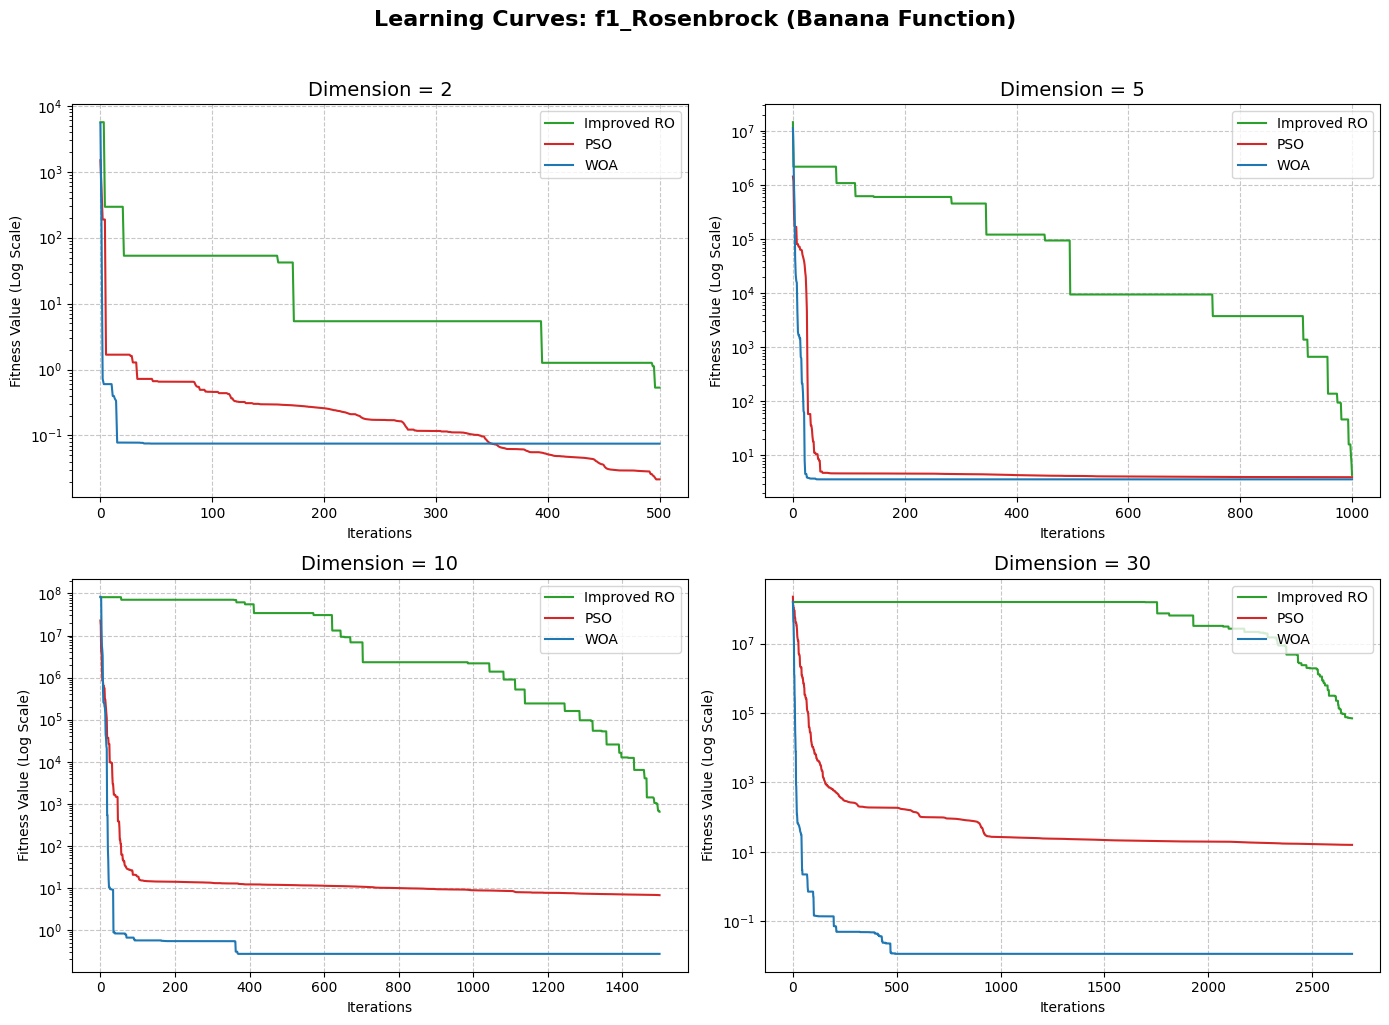

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 專屬 f1 (Rosenbrock) 的 4 維度學習曲線繪圖
# ==========================================
def generate_f1_learning_curve():
    print("🚀 開始繪製 f1 (Rosenbrock) 的 4 維度學習曲線圖...")

    # f1 的基本設定
    func = f1_rosenbrock
    name = "f1_Rosenbrock"
    lb, ub = -5.0, 5.0
    dimensions = [2, 5, 10, 30]

    # 覆蓋全域邊界變數 (給演算法內部使用)
    global lb_global, ub_global
    lb_global, ub_global = lb, ub

    # 設定畫布：2x2 的子圖排列
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Learning Curves: {name} (Banana Function)", fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()

    for i, D in enumerate(dimensions):
        print(f"⏳ 正在計算 D={D} ...")
        # 執行演算法並取得歷史適應值
        _, score_ro = run_Improved_RO(D, func)
        _, score_pso = run_PSO(D, func)
        _, score_woa = run_WOA(D, func)

        # 選取對應的子圖
        ax = axes[i]

        # 繪製曲線
        ax.plot(score_ro, label='Improved RO', color='#2ca02c', linewidth=1.5)  # 綠色
        ax.plot(score_pso, label='PSO', color='#d62728', linewidth=1.5)          # 紅色
        ax.plot(score_woa, label='WOA', color='#1f77b4', linewidth=1.5)          # 藍色

        # 設定圖表標籤與格式
        ax.set_title(f"Dimension = {D}", fontsize=14)
        ax.set_xlabel("Iterations")
        ax.set_ylabel("Fitness Value (Log Scale)")

        # 使用對數尺度 (Log Scale) 以便清楚觀察微小誤差的收斂
        ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')

    plt.tight_layout()

    # 存檔
    filename = f"Learning_Curve_{name}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\n✅ 繪製完成！已自動存檔為 {filename}")

    plt.show()

# 執行繪圖
generate_f1_learning_curve()



第二式測式

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib as mpl

# 解決繪圖中文顯示問題
mpl.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 定義 f2 (Rastrigin) 函數與參數
# ==========================================
def f2_rastrigin(x):
    D = len(x)
    return 10.0 * D + np.sum(x**2.0 - 10.0 * np.cos(2.0 * math.pi * x))

# f2 的變數範圍 (根據作業表1)
lb, ub = -5.12, 5.12

# ==========================================
# (保留原有的三個演算法函數，請確保 run_Improved_RO, run_PSO, run_WOA 已經在記憶體中)
# 註：這裡假設您已經執行過前面的演算法定義區塊。
# ==========================================

# ==========================================
# 2. 執行 f2 多維度測試與產生報表
# ==========================================
dimensions = [2, 5, 10, 30]
algorithms = {'Improved RO': run_Improved_RO, 'PSO': run_PSO, 'WOA': run_WOA}
all_results = []

print("🚀 開始進行 f2 (Rastrigin) 綜合壓力測試...\n")

for D in dimensions:
    theory_score = 0.0
    theory_pos = np.zeros(D) # f2 的最佳解是 (0, 0, ..., 0)

    for algo_name, algo_func in algorithms.items():
        # 注意：這裡傳入的是 f2_rastrigin
        history_pos, history_score = algo_func(D, f2_rastrigin)
        total_iters = len(history_score)

        if total_iters <= 10:
            target_indices = list(range(total_iters))
        else:
            target_indices = list(range(5)) + list(range(total_iters - 5, total_iters))

        for idx in target_indices:
            current_pos = history_pos[idx]
            current_score = history_score[idx]

            pos_str = np.array2string(current_pos[:3], precision=4, separator=', ')
            theory_pos_str = np.array2string(theory_pos[:3], precision=1, separator=', ')
            if D > 3:
                pos_str = pos_str.replace(']', ', ...]')
                theory_pos_str = theory_pos_str.replace(']', ', ...]')

            error_sq = (current_score - theory_score)**2

            all_results.append({
                "測試函數": "f2",
                "維度(D)": D,
                "演算法": algo_name,
                "第幾代": idx + 1,
                "搜尋位置 (前3維)": pos_str,
                "理想位置 (x*)": theory_pos_str,
                "函數值 f(x_best)": f"{current_score:.6e}",
                "誤差平方 (|f-f_min|^2)": f"{error_sq:.6e}"
            })

df_results = pd.DataFrame(all_results)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.unicode.east_asian_width', True)

print("✅ f2 (Rastrigin) 測試完成！結果報表如下：")
print(df_results)
df_results.to_csv("f2_results_with_error.csv", index=False, encoding='utf-8-sig')

🚀 開始進行 f2 (Rastrigin) 綜合壓力測試...

✅ f2 (Rastrigin) 測試完成！結果報表如下：
    測試函數  維度(D)       演算法  第幾代                              搜尋位置 (前3維)      理想位置 (x*) 函數值 f(x_best) 誤差平方 (|f-f_min|^2)
0         f2        2  Improved RO       1                              [1.9033, 2.0882]           [0., 0.]     1.127195e+01           1.270569e+02
1         f2        2  Improved RO       2                              [1.9033, 2.0882]           [0., 0.]     1.127195e+01           1.270569e+02
2         f2        2  Improved RO       3                              [1.9033, 2.0882]           [0., 0.]     1.127195e+01           1.270569e+02
3         f2        2  Improved RO       4                              [1.9033, 2.0882]           [0., 0.]     1.127195e+01           1.270569e+02
4         f2        2  Improved RO       5                              [1.9033, 2.0882]           [0., 0.]     1.127195e+01           1.270569e+02
5         f2        2  Improved RO     497                            [-0.9928

第二式做圖

🚀 開始繪製 f2 (Rastrigin) 的 4 維度學習曲線圖...
⏳ 正在計算 D=2 ...
⏳ 正在計算 D=5 ...
⏳ 正在計算 D=10 ...
⏳ 正在計算 D=30 ...



✅ 繪製完成！已自動存檔為 Learning_Curve_f2_Rastrigin.png


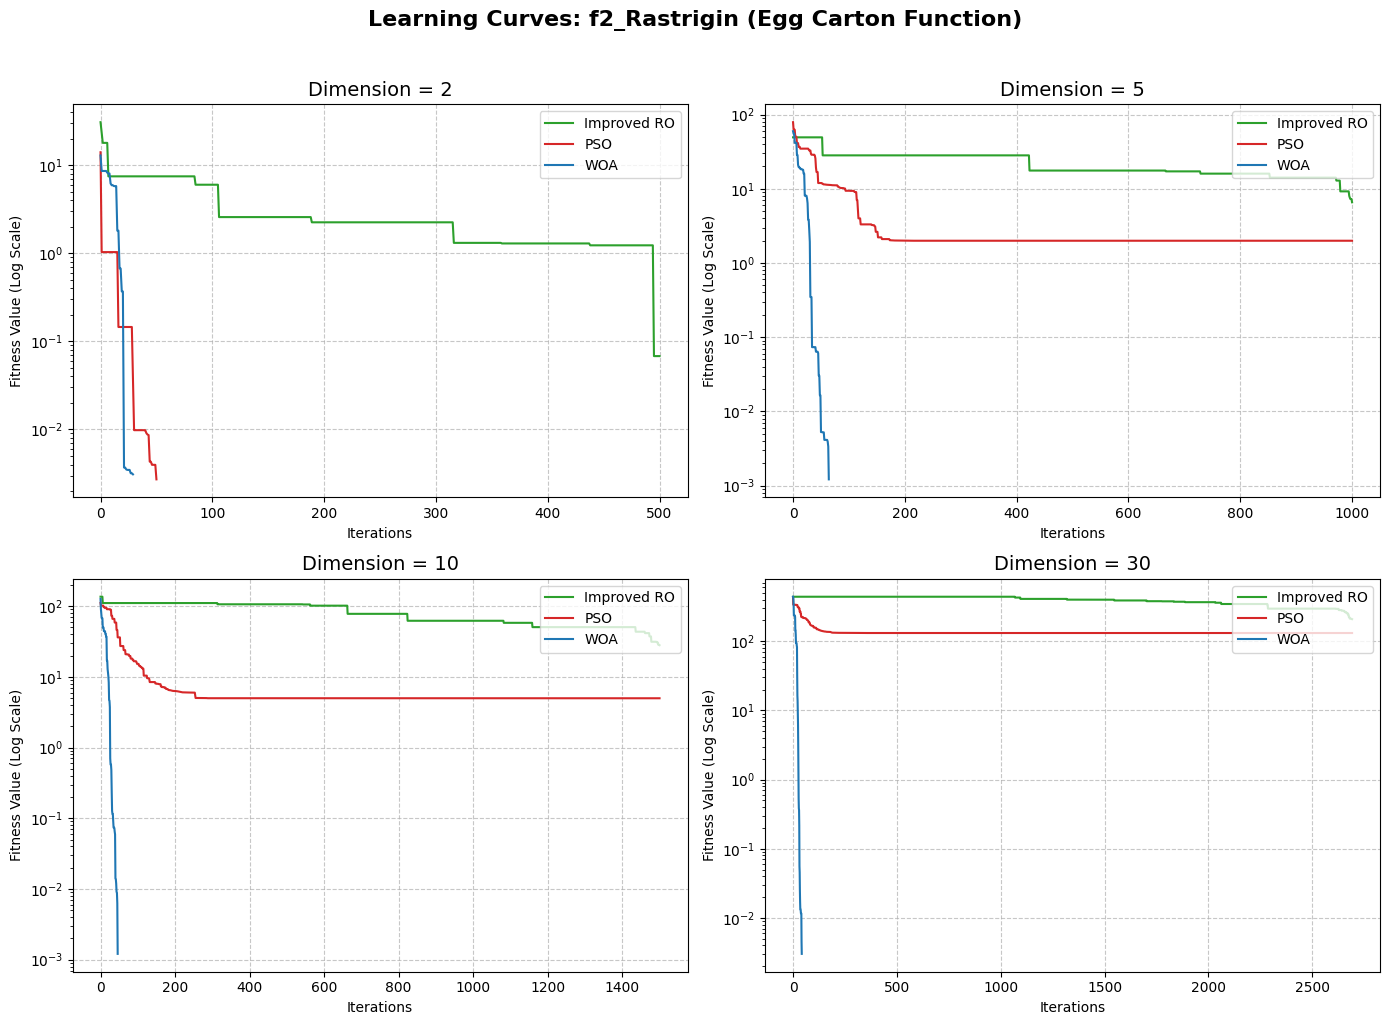

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 專屬 f2 (Rastrigin) 的 4 維度學習曲線繪圖
# ==========================================
def generate_f2_learning_curve():
    print("🚀 開始繪製 f2 (Rastrigin) 的 4 維度學習曲線圖...")

    # f2 的基本設定 (請確認上方已定義 f2_rastrigin)
    func = f2_rastrigin
    name = "f2_Rastrigin"
    lb, ub = -5.12, 5.12  # Rastrigin 的標準邊界
    dimensions = [2, 5, 10, 30]

    # 覆蓋全域邊界變數 (給演算法內部使用)
    global lb_global, ub_global
    lb_global, ub_global = lb, ub

    # 設定畫布：2x2 的子圖排列
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Learning Curves: {name} (Egg Carton Function)", fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()

    for i, D in enumerate(dimensions):
        print(f"⏳ 正在計算 D={D} ...")
        # 執行演算法並取得歷史適應值
        _, score_ro = run_Improved_RO(D, func)
        _, score_pso = run_PSO(D, func)
        _, score_woa = run_WOA(D, func)

        ax = axes[i]

        # 繪製曲線
        ax.plot(score_ro, label='Improved RO', color='#2ca02c', linewidth=1.5)
        ax.plot(score_pso, label='PSO', color='#d62728', linewidth=1.5)
        ax.plot(score_woa, label='WOA', color='#1f77b4', linewidth=1.5)

        ax.set_title(f"Dimension = {D}", fontsize=14)
        ax.set_xlabel("Iterations")
        ax.set_ylabel("Fitness Value (Log Scale)")

        ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')

    plt.tight_layout()

    # 存檔
    filename = f"Learning_Curve_{name}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\n✅ 繪製完成！已自動存檔為 {filename}")

    plt.show()

# 執行繪圖
generate_f2_learning_curve()

第三式測式

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib as mpl

# 解決繪圖中文顯示問題
mpl.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 定義 f3 (Schwefel) 函數與參數
# ==========================================
def f3_schwefel(x):
    # f3 公式: sum(-x * sin(sqrt(|x|)))
    return np.sum(-x * np.sin(np.sqrt(np.abs(x))))

# f3 的變數範圍
lb_f3, ub_f3 = -500.0, 500.0

# 為了讓演算法函數吃到正確的範圍，我們需要稍微修改一下全域變數
# (在真實開發中通常會把它寫成 class 或傳遞參數，這裡為了作業方便我們直接覆蓋)
global lb, ub
lb, ub = lb_f3, ub_f3

# ==========================================
# (保留原有的三個演算法 run_Improved_RO, run_PSO, run_WOA)
# ==========================================

# ==========================================
# 2. 執行 f3 多維度測試與產生報表
# ==========================================
dimensions = [2, 5, 10, 30]
algorithms = {'Improved RO': run_Improved_RO, 'PSO': run_PSO, 'WOA': run_WOA}
all_results = []

print("🚀 開始進行 f3 (Schwefel) 綜合壓力測試...\n")

for D in dimensions:
    theory_score = 0.0
    theory_pos = np.zeros(D) # 依作業設定

    for algo_name, algo_func in algorithms.items():
        history_pos, history_score = algo_func(D, f3_schwefel)
        total_iters = len(history_score)

        if total_iters <= 10:
            target_indices = list(range(total_iters))
        else:
            target_indices = list(range(5)) + list(range(total_iters - 5, total_iters))

        for idx in target_indices:
            current_pos = history_pos[idx]
            current_score = history_score[idx]

            pos_str = np.array2string(current_pos[:3], precision=4, separator=', ')
            theory_pos_str = np.array2string(theory_pos[:3], precision=1, separator=', ')
            if D > 3:
                pos_str = pos_str.replace(']', ', ...]')
                theory_pos_str = theory_pos_str.replace(']', ', ...]')

            # 計算與作業理論值 0 的誤差平方
            error_sq = (current_score - theory_score)**2

            all_results.append({
                "測試函數": "f3",
                "維度(D)": D,
                "演算法": algo_name,
                "第幾代": idx + 1,
                "搜尋位置 (前3維)": pos_str,
                "理想位置 (x*)": theory_pos_str,
                "函數值 f(x_best)": f"{current_score:.6e}",
                "誤差平方 (|f-0|^2)": f"{error_sq:.6e}"
            })

df_results = pd.DataFrame(all_results)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.unicode.east_asian_width', True)

print("✅ f3 (Schwefel) 測試完成！結果報表如下：")
print(df_results)
df_results.to_csv("f3_results_with_error.csv", index=False, encoding='utf-8-sig')



🚀 開始進行 f3 (Schwefel) 綜合壓力測試...

✅ f3 (Schwefel) 測試完成！結果報表如下：
    測試函數  維度(D)       演算法  第幾代                        搜尋位置 (前3維)      理想位置 (x*) 函數值 f(x_best) 誤差平方 (|f-0|^2)
0         f3        2  Improved RO       1                  [-215.5642,  412.3502]           [0., 0.]    -2.253345e+02       5.077564e+04
1         f3        2  Improved RO       2                  [-215.5642,  412.3502]           [0., 0.]    -2.253345e+02       5.077564e+04
2         f3        2  Improved RO       3                  [-215.5642,  412.3502]           [0., 0.]    -2.253345e+02       5.077564e+04
3         f3        2  Improved RO       4                          [-500., -500.]           [0., 0.]    -3.611783e+02       1.304498e+05
4         f3        2  Improved RO       5                  [ 386.5851, -500.    ]           [0., 0.]    -4.611762e+02       2.126835e+05
5         f3        2  Improved RO     497                    [420.3054, 415.5329]           [0., 0.]    -8.341951e+02       6.958814e+05
6 

第三式繪圖

🚀 開始繪製 f3 (Schwefel) 的 4 維度學習曲線圖...
⏳ 正在計算 D=2 ...


/tmp/ipykernel_2464/3824674730.py:43: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


⏳ 正在計算 D=5 ...
⏳ 正在計算 D=10 ...
⏳ 正在計算 D=30 ...



✅ 繪製完成！已自動存檔為 Learning_Curve_f3_Schwefel.png


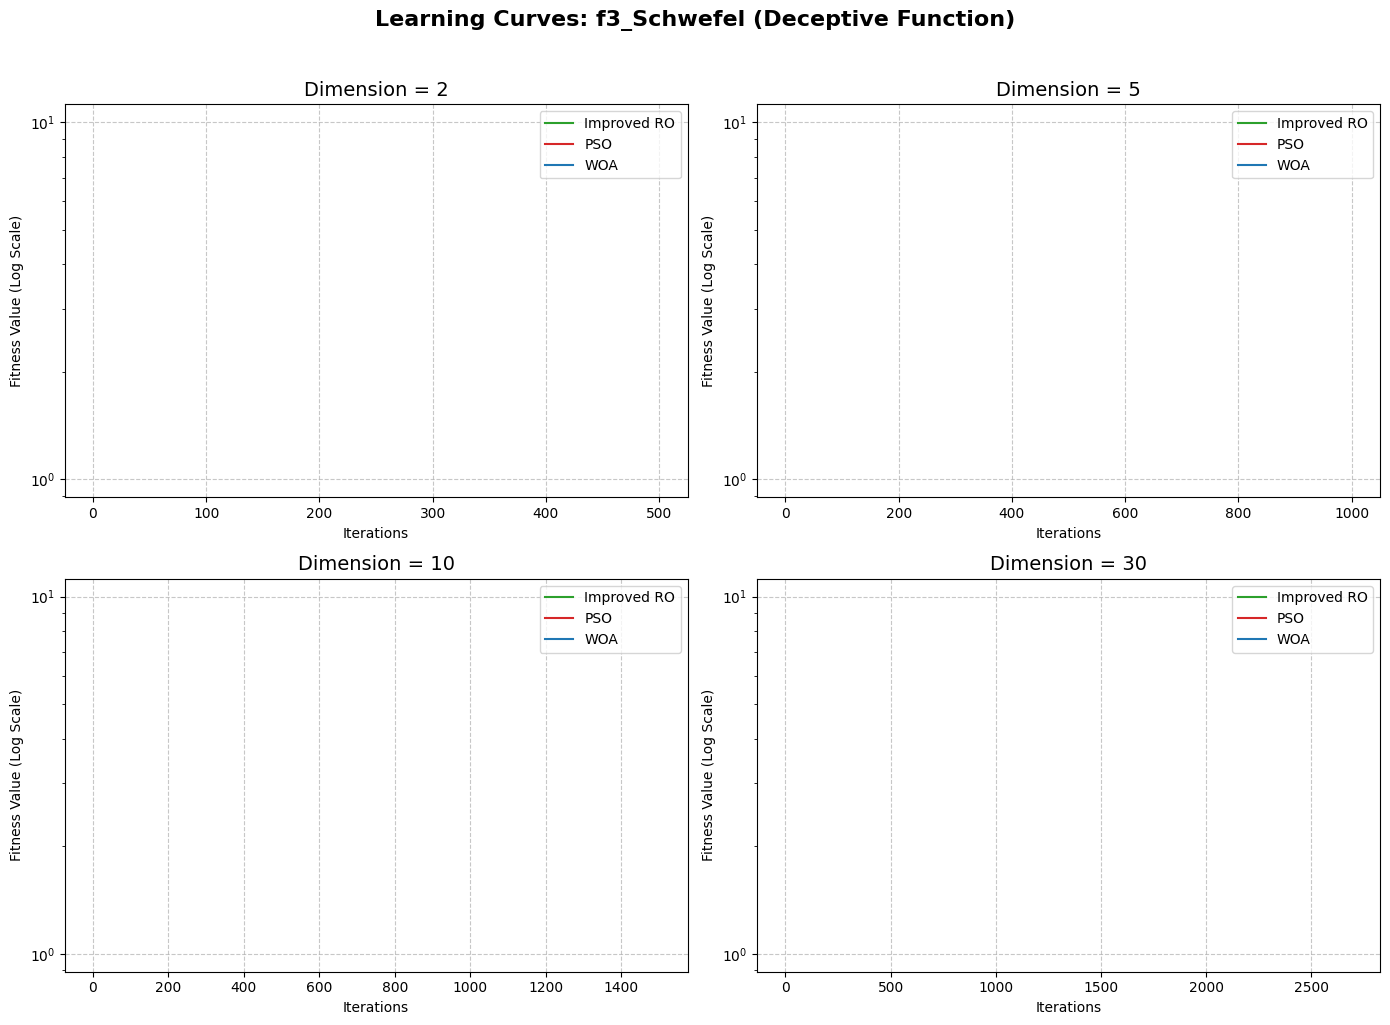

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 專屬 f3 (Schwefel) 的 4 維度學習曲線繪圖
# ==========================================
def generate_f3_learning_curve():
    print("🚀 開始繪製 f3 (Schwefel) 的 4 維度學習曲線圖...")

    # f3 的基本設定 (邊界範圍通常極大)
    func = f3_schwefel
    name = "f3_Schwefel"
    lb, ub = -500.0, 500.0  # Schwefel 的標準邊界
    dimensions = [2, 5, 10, 30]

    # 覆蓋全域邊界變數 (給演算法內部使用)
    global lb_global, ub_global
    lb_global, ub_global = lb, ub

    # 設定畫布：2x2 的子圖排列
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Learning Curves: {name} (Deceptive Function)", fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()

    for i, D in enumerate(dimensions):
        print(f"⏳ 正在計算 D={D} ...")
        # 執行演算法並取得歷史適應值
        _, score_ro = run_Improved_RO(D, func)
        _, score_pso = run_PSO(D, func)
        _, score_woa = run_WOA(D, func)

        ax = axes[i]

        # 繪製曲線
        ax.plot(score_ro, label='Improved RO', color='#2ca02c', linewidth=1.5)
        ax.plot(score_pso, label='PSO', color='#d62728', linewidth=1.5)
        ax.plot(score_woa, label='WOA', color='#1f77b4', linewidth=1.5)

        ax.set_title(f"Dimension = {D}", fontsize=14)
        ax.set_xlabel("Iterations")
        ax.set_ylabel("Fitness Value (Log Scale)")

        ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')

    plt.tight_layout()

    # 存檔
    filename = f"Learning_Curve_{name}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\n✅ 繪製完成！已自動存檔為 {filename}")

    plt.show()

# 執行繪圖
generate_f3_learning_curve()

第四式測式

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib as mpl

# 解決繪圖中文顯示問題
mpl.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 定義 f4 (Sphere) 函數與參數
# ==========================================
def f4_sphere(x):
    # f4 公式: sum(x^2)
    return np.sum(x**2)

# f4 的變數範圍 (通常 Sphere 設為 -100 到 100)
lb_f4, ub_f4 = -100.0, 100.0

# 覆蓋全域變數範圍給演算法使用
global lb, ub
lb, ub = lb_f4, ub_f4

# ==========================================
# (保留原有的三個演算法 run_Improved_RO, run_PSO, run_WOA)
# ==========================================

# ==========================================
# 2. 執行 f4 多維度測試與產生報表
# ==========================================
dimensions = [2, 5, 10, 30]
algorithms = {'Improved RO': run_Improved_RO, 'PSO': run_PSO, 'WOA': run_WOA}
all_results = []

print("🚀 開始進行 f4 (Sphere) 綜合壓力測試...\n")

for D in dimensions:
    theory_score = 0.0
    theory_pos = np.zeros(D) # 完美解在 (0, 0, ..., 0)

    for algo_name, algo_func in algorithms.items():
        history_pos, history_score = algo_func(D, f4_sphere)
        total_iters = len(history_score)

        if total_iters <= 10:
            target_indices = list(range(total_iters))
        else:
            target_indices = list(range(5)) + list(range(total_iters - 5, total_iters))

        for idx in target_indices:
            current_pos = history_pos[idx]
            current_score = history_score[idx]

            pos_str = np.array2string(current_pos[:3], precision=4, separator=', ')
            theory_pos_str = np.array2string(theory_pos[:3], precision=1, separator=', ')
            if D > 3:
                pos_str = pos_str.replace(']', ', ...]')
                theory_pos_str = theory_pos_str.replace(']', ', ...]')

            error_sq = (current_score - theory_score)**2

            all_results.append({
                "測試函數": "f4",
                "維度(D)": D,
                "演算法": algo_name,
                "第幾代": idx + 1,
                "搜尋位置 (前3維)": pos_str,
                "理想位置 (x*)": theory_pos_str,
                "函數值 f(x_best)": f"{current_score:.6e}",
                "誤差平方 (|f-0|^2)": f"{error_sq:.6e}"
            })

df_results = pd.DataFrame(all_results)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.unicode.east_asian_width', True)

print("✅ f4 (Sphere) 測試完成！結果報表如下：")
print(df_results)
df_results.to_csv("f4_results_with_error.csv", index=False, encoding='utf-8-sig')



🚀 開始進行 f4 (Sphere) 綜合壓力測試...

✅ f4 (Sphere) 測試完成！結果報表如下：
    測試函數  維度(D)       演算法  第幾代                     搜尋位置 (前3維)      理想位置 (x*) 函數值 f(x_best) 誤差平方 (|f-0|^2)
0         f4        2  Improved RO       1                   [34.5002, -7.951 ]           [0., 0.]     1.253482e+03       1.571216e+06
1         f4        2  Improved RO       2                 [ -1.1998, -22.833 ]           [0., 0.]     5.227852e+02       2.733044e+05
2         f4        2  Improved RO       3                 [ -1.1998, -22.833 ]           [0., 0.]     5.227852e+02       2.733044e+05
3         f4        2  Improved RO       4                 [ -1.1998, -22.833 ]           [0., 0.]     5.227852e+02       2.733044e+05
4         f4        2  Improved RO       5                 [ -1.1998, -22.833 ]           [0., 0.]     5.227852e+02       2.733044e+05
5         f4        2  Improved RO     497                     [0.1922, 0.4088]           [0., 0.]     2.040529e-01       4.163757e-02
6         f4        2  Impr

第四式繪圖

🚀 開始繪製 f4 (Sphere) 的 4 維度學習曲線圖...
⏳ 正在計算 D=2 ...
⏳ 正在計算 D=5 ...
⏳ 正在計算 D=10 ...
⏳ 正在計算 D=30 ...



✅ 繪製完成！已自動存檔為 Learning_Curve_f4_Sphere.png


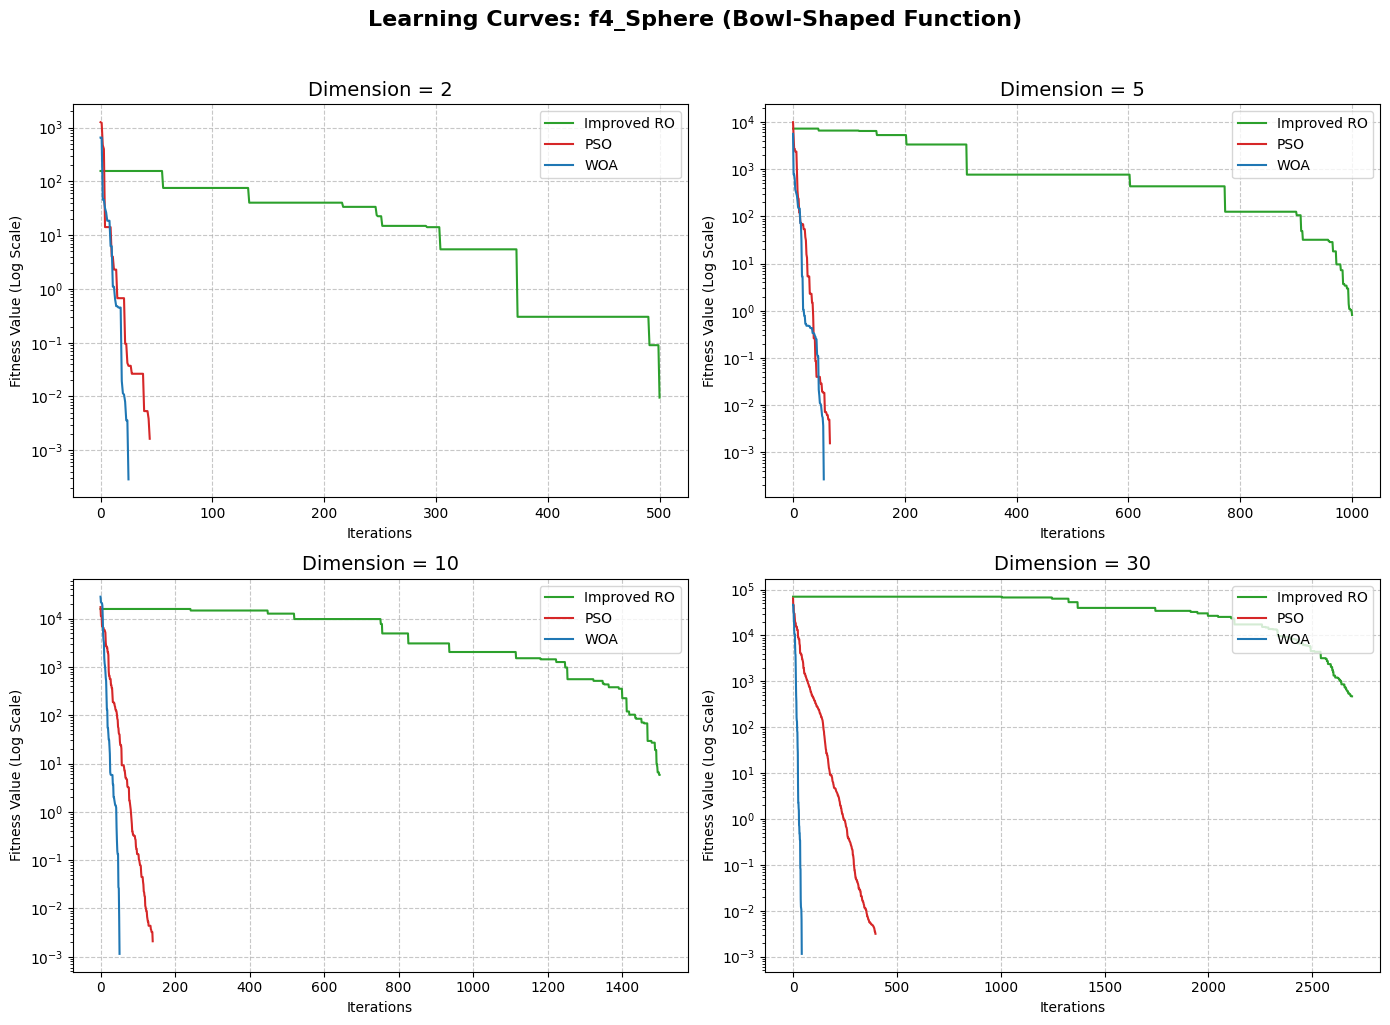

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 專屬 f4 (Sphere) 的 4 維度學習曲線繪圖
# ==========================================
def generate_f4_learning_curve():
    print("🚀 開始繪製 f4 (Sphere) 的 4 維度學習曲線圖...")

    # f4 的基本設定 (範圍通常設為 -100 到 100 以測試長距離下坡)
    func = f4_sphere # 請確認您最上方有定義此函數
    name = "f4_Sphere"
    lb, ub = -100.0, 100.0
    dimensions = [2, 5, 10, 30]

    # 覆蓋全域邊界變數
    global lb_global, ub_global
    lb_global, ub_global = lb, ub

    # 設定畫布：2x2 的子圖排列
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Learning Curves: {name} (Bowl-Shaped Function)", fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()

    for i, D in enumerate(dimensions):
        print(f"⏳ 正在計算 D={D} ...")
        # 執行演算法並取得歷史適應值
        _, score_ro = run_Improved_RO(D, func)
        _, score_pso = run_PSO(D, func)
        _, score_woa = run_WOA(D, func)

        ax = axes[i]

        # 繪製曲線
        ax.plot(score_ro, label='Improved RO', color='#2ca02c', linewidth=1.5)
        ax.plot(score_pso, label='PSO', color='#d62728', linewidth=1.5)
        ax.plot(score_woa, label='WOA', color='#1f77b4', linewidth=1.5)

        ax.set_title(f"Dimension = {D}", fontsize=14)
        ax.set_xlabel("Iterations")
        ax.set_ylabel("Fitness Value (Log Scale)")

        ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')

    plt.tight_layout()

    # 存檔
    filename = f"Learning_Curve_{name}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\n✅ 繪製完成！已自動存檔為 {filename}")

    plt.show()

# 執行繪圖
generate_f4_learning_curve()

第五式測式

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib as mpl

# 解決繪圖中文顯示問題
mpl.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 定義真正的 f5 (Ackley) 函數
# ==========================================
def f5_ackley(x):
    D = len(x)
    # 第一個 EXP 項
    sum_sq = np.sum(x**2)
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / D))
    # 第二個 EXP 項
    sum_cos = np.sum(np.cos(2.0 * np.pi * x))
    term2 = -np.exp(sum_cos / D)

    return term1 + term2 + 20.0 + np.exp(1)

# Ackley 的變數範圍 (依標準設為 -32 到 32)
lb_f5, ub_f5 = -32.0, 32.0

# 覆蓋全域變數
global lb, ub
lb, ub = lb_f5, ub_f5

# ==========================================
# 2. 執行 f5 (Ackley) 綜合壓力測試
# ==========================================
dimensions = [2, 5, 10, 30]
algorithms = {'Improved RO': run_Improved_RO, 'PSO': run_PSO, 'WOA': run_WOA}
all_results = []

print("🚀 開始進行真正的 f5 (Ackley) 綜合壓力測試...\n")

for D in dimensions:
    theory_score = 0.0
    theory_pos = np.zeros(D)

    for algo_name, algo_func in algorithms.items():
        history_pos, history_score = algo_func(D, f5_ackley)
        total_iters = len(history_score)

        # 取前5代與最後5代
        if total_iters <= 10:
            target_indices = list(range(total_iters))
        else:
            target_indices = list(range(5)) + list(range(total_iters - 5, total_iters))

        for idx in target_indices:
            current_pos = history_pos[idx]
            current_score = history_score[idx]

            pos_str = np.array2string(current_pos[:3], precision=4, separator=', ')
            theory_pos_str = np.array2string(theory_pos[:3], precision=1, separator=', ')
            if D > 3:
                pos_str = pos_str.replace(']', ', ...]')

            error_sq = (current_score - theory_score)**2

            all_results.append({
                "測試函數": "f5 (Ackley)",
                "維度(D)": D,
                "演算法": algo_name,
                "第幾代": idx + 1,
                "搜尋位置 (前3維)": pos_str,
                "理想位置 (x*)": theory_pos_str,
                "函數值 f(x_best)": f"{current_score:.6e}",
                "誤差平方 (|f-0|^2)": f"{error_sq:.6e}"
            })

df_results = pd.DataFrame(all_results)
print("✅ f5 (Ackley) 測試完成！")
print(df_results)
df_results.to_csv("f5_ackley_results.csv", index=False, encoding='utf-8-sig')



🚀 開始進行真正的 f5 (Ackley) 綜合壓力測試...

✅ f5 (Ackley) 測試完成！
        測試函數  維度(D)       演算法  第幾代                              搜尋位置 (前3維) 理想位置 (x*) 函數值 f(x_best) 誤差平方 (|f-0|^2)
0    f5 (Ackley)        2  Improved RO       1                          [-11.8739, -14.5144]      [0., 0.]     2.044463e+01       4.179827e+02
1    f5 (Ackley)        2  Improved RO       2                                  [-32., -32.]      [0., 0.]     1.996677e+01       3.986719e+02
2    f5 (Ackley)        2  Improved RO       3                                  [-32., -32.]      [0., 0.]     1.996677e+01       3.986719e+02
3    f5 (Ackley)        2  Improved RO       4                            [-7.2406,  2.7369]      [0., 0.]     1.503679e+01       2.261050e+02
4    f5 (Ackley)        2  Improved RO       5                            [-7.2406,  2.7369]      [0., 0.]     1.503679e+01       2.261050e+02
5    f5 (Ackley)        2  Improved RO     497                            [ 0.0936, -0.0201]      [0., 0.]     4.98100

第五式繪圖

🚀 開始繪製 f5 (Ackley) 的 4 維度學習曲線圖...
⏳ 正在計算 D=2 ...
⏳ 正在計算 D=5 ...
⏳ 正在計算 D=10 ...
⏳ 正在計算 D=30 ...



✅ 繪製完成！已自動存檔為 Learning_Curve_f5_Ackley.png


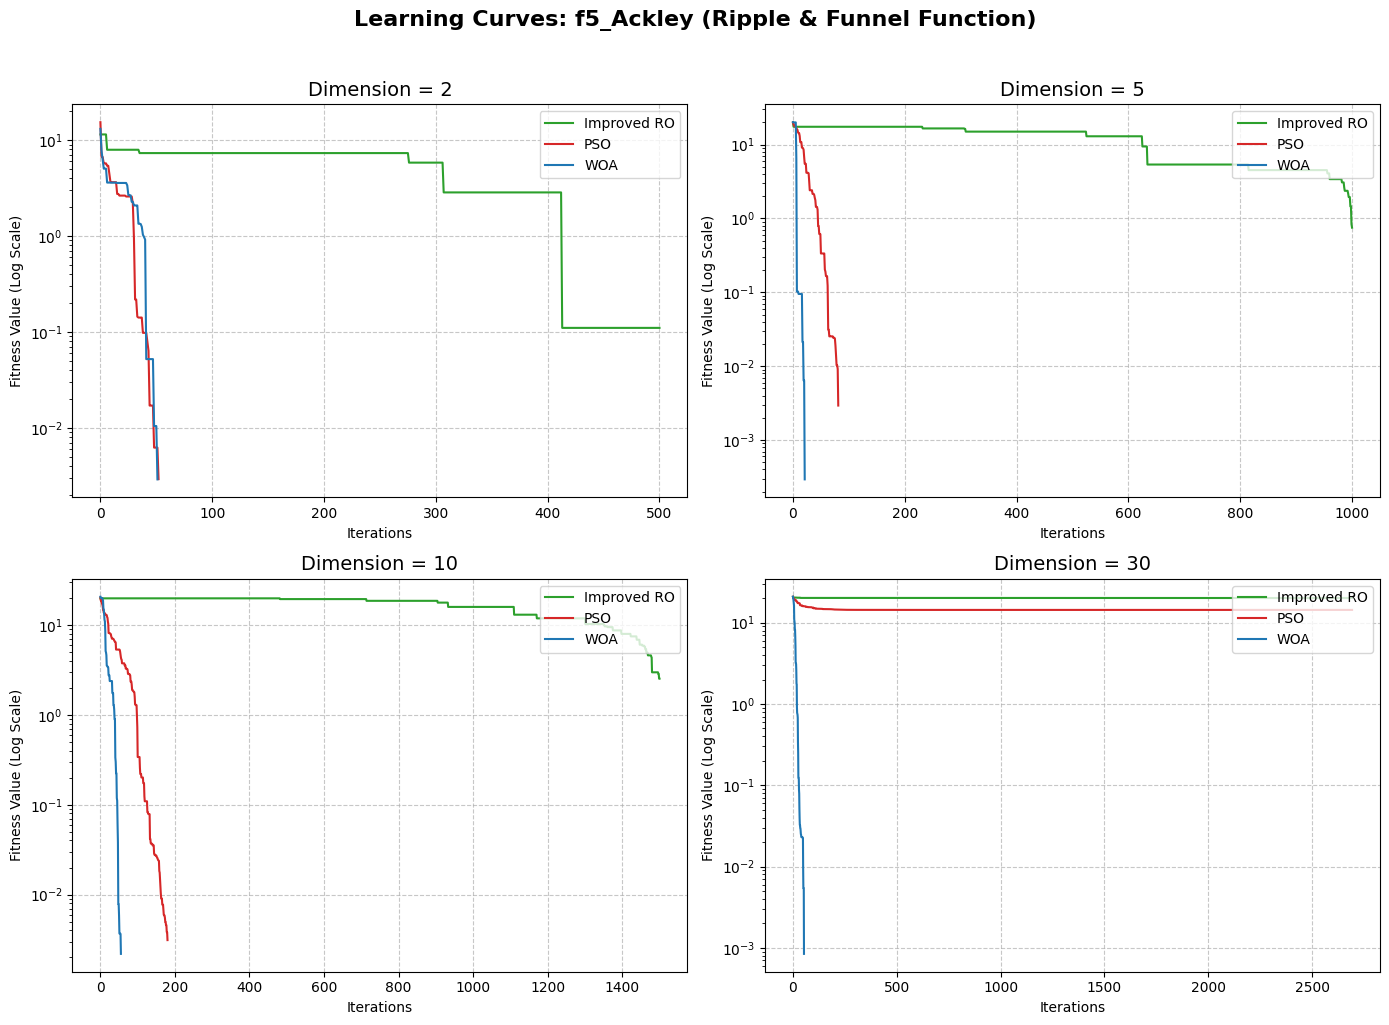

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 專屬 f5 (Ackley) 的 4 維度學習曲線繪圖
# ==========================================
def generate_f5_learning_curve():
    print("🚀 開始繪製 f5 (Ackley) 的 4 維度學習曲線圖...")

    # f5 的基本設定 (Ackley 標準邊界通常為 -32 到 32)
    func = f5_ackley # 請確認您最上方有定義此函數
    name = "f5_Ackley"
    lb, ub = -32.0, 32.0
    dimensions = [2, 5, 10, 30]

    # 覆蓋全域邊界變數
    global lb_global, ub_global
    lb_global, ub_global = lb, ub

    # 設定畫布：2x2 的子圖排列
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Learning Curves: {name} (Ripple & Funnel Function)", fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()

    for i, D in enumerate(dimensions):
        print(f"⏳ 正在計算 D={D} ...")
        # 執行演算法並取得歷史適應值
        _, score_ro = run_Improved_RO(D, func)
        _, score_pso = run_PSO(D, func)
        _, score_woa = run_WOA(D, func)

        ax = axes[i]

        # 繪製曲線
        ax.plot(score_ro, label='Improved RO', color='#2ca02c', linewidth=1.5)
        ax.plot(score_pso, label='PSO', color='#d62728', linewidth=1.5)
        ax.plot(score_woa, label='WOA', color='#1f77b4', linewidth=1.5)

        ax.set_title(f"Dimension = {D}", fontsize=14)
        ax.set_xlabel("Iterations")
        ax.set_ylabel("Fitness Value (Log Scale)")

        ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')

    plt.tight_layout()

    # 存檔
    filename = f"Learning_Curve_{name}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\n✅ 繪製完成！已自動存檔為 {filename}")

    plt.show()

# 執行繪圖
generate_f5_learning_curve()

2D最佳化路徑圖

🚀 開始批次產生 5 張 2D 等高線軌跡圖...

正在處理 f1_Rosenbrock ...


✅ f1_Rosenbrock 繪製完成！已存檔為 path_f1_Rosenbrock.png


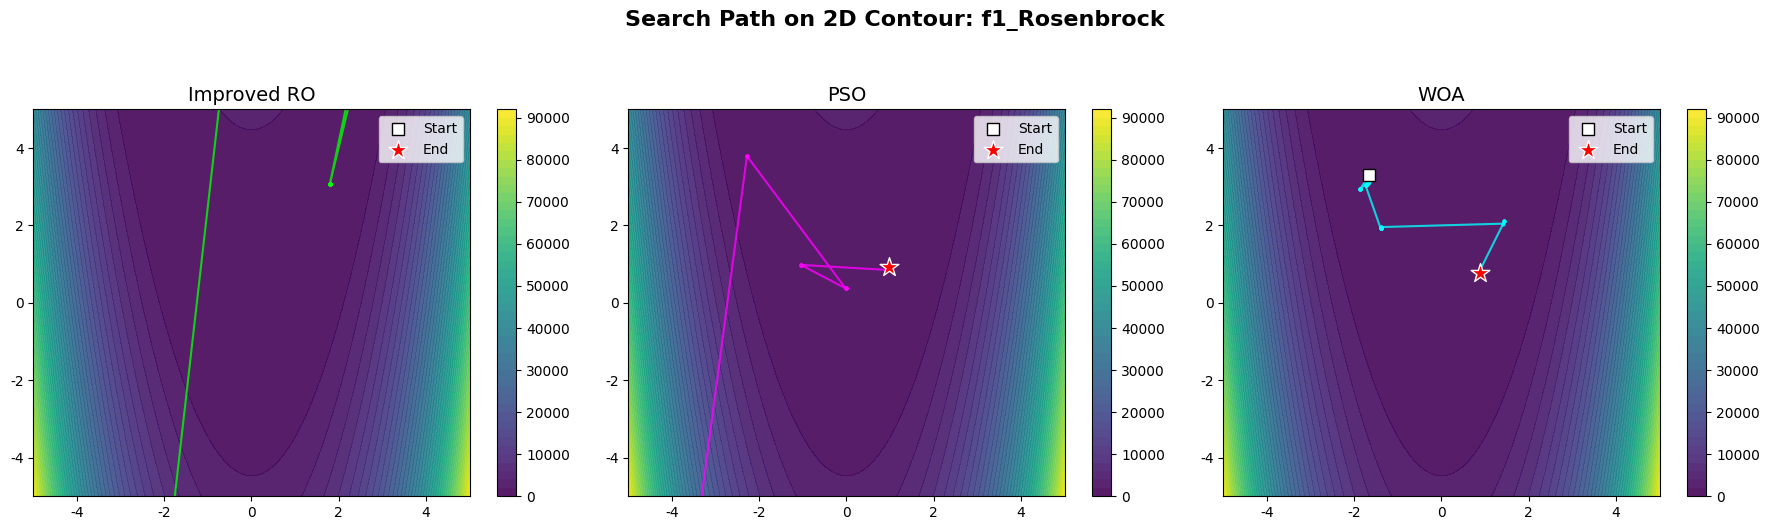


正在處理 f2_Rastrigin ...


✅ f2_Rastrigin 繪製完成！已存檔為 path_f2_Rastrigin.png


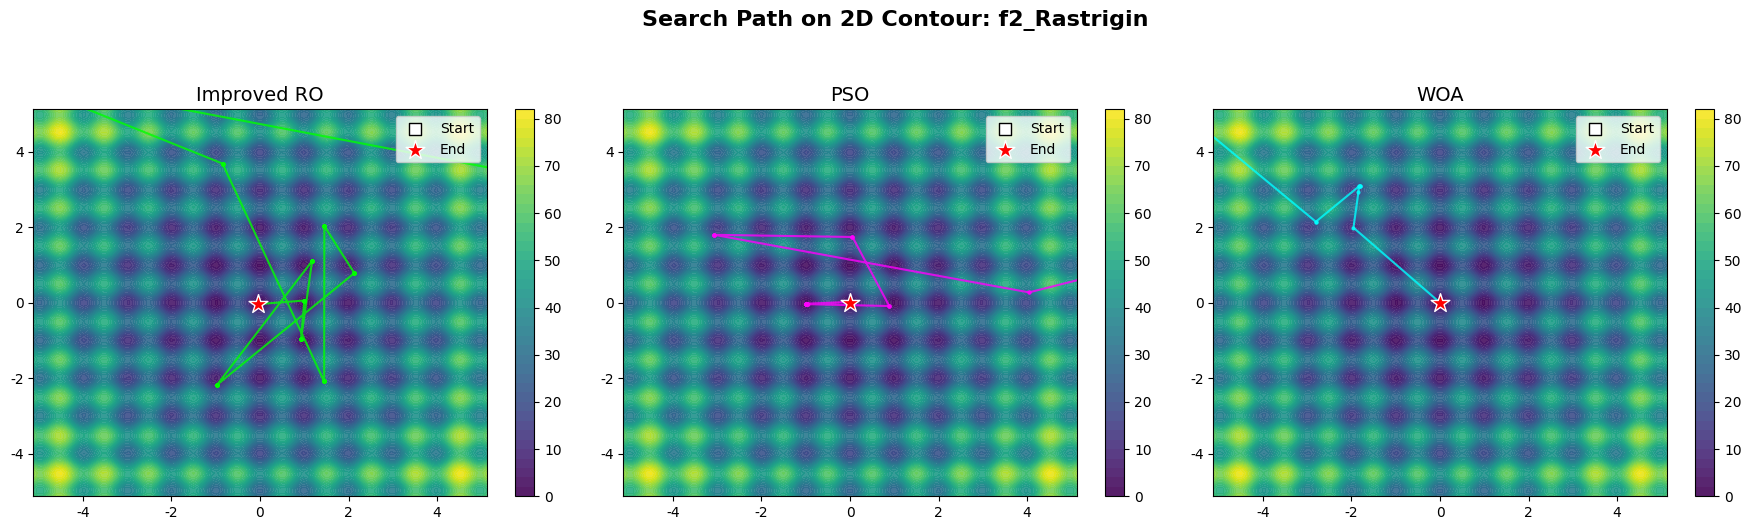


正在處理 f3_Schwefel ...


✅ f3_Schwefel 繪製完成！已存檔為 path_f3_Schwefel.png


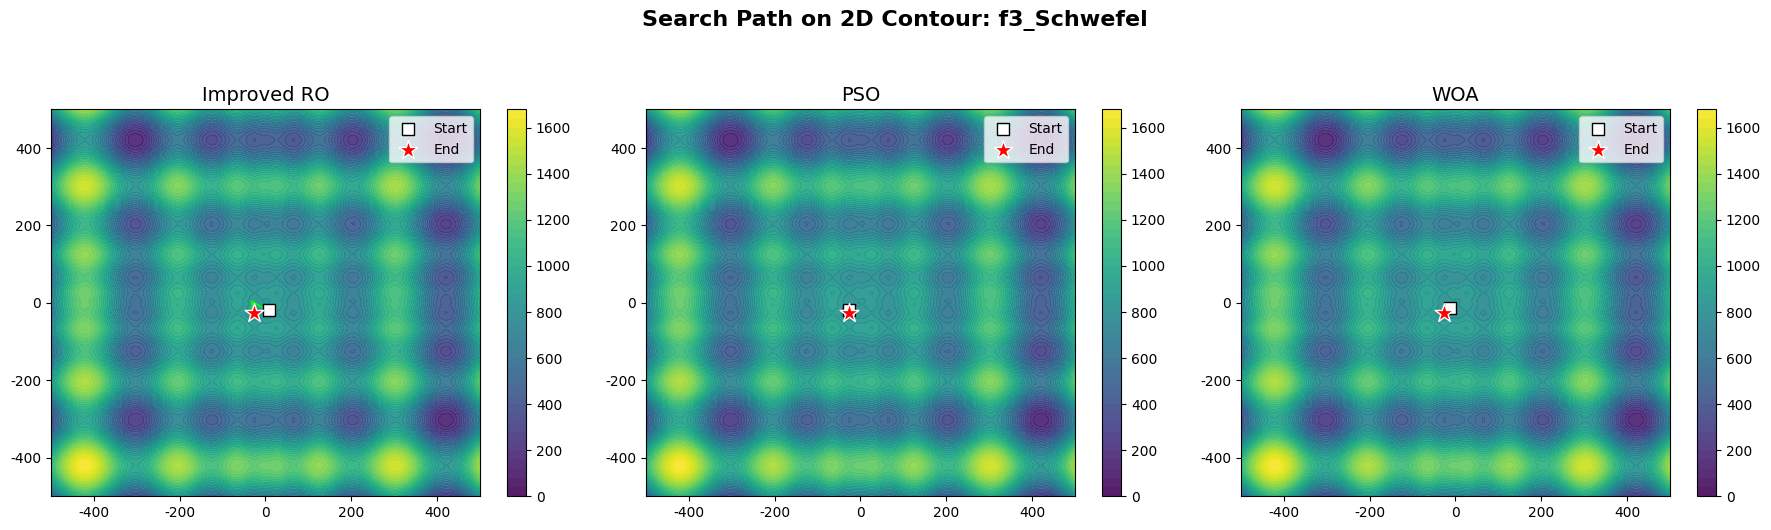


正在處理 f4_Sphere ...


✅ f4_Sphere 繪製完成！已存檔為 path_f4_Sphere.png


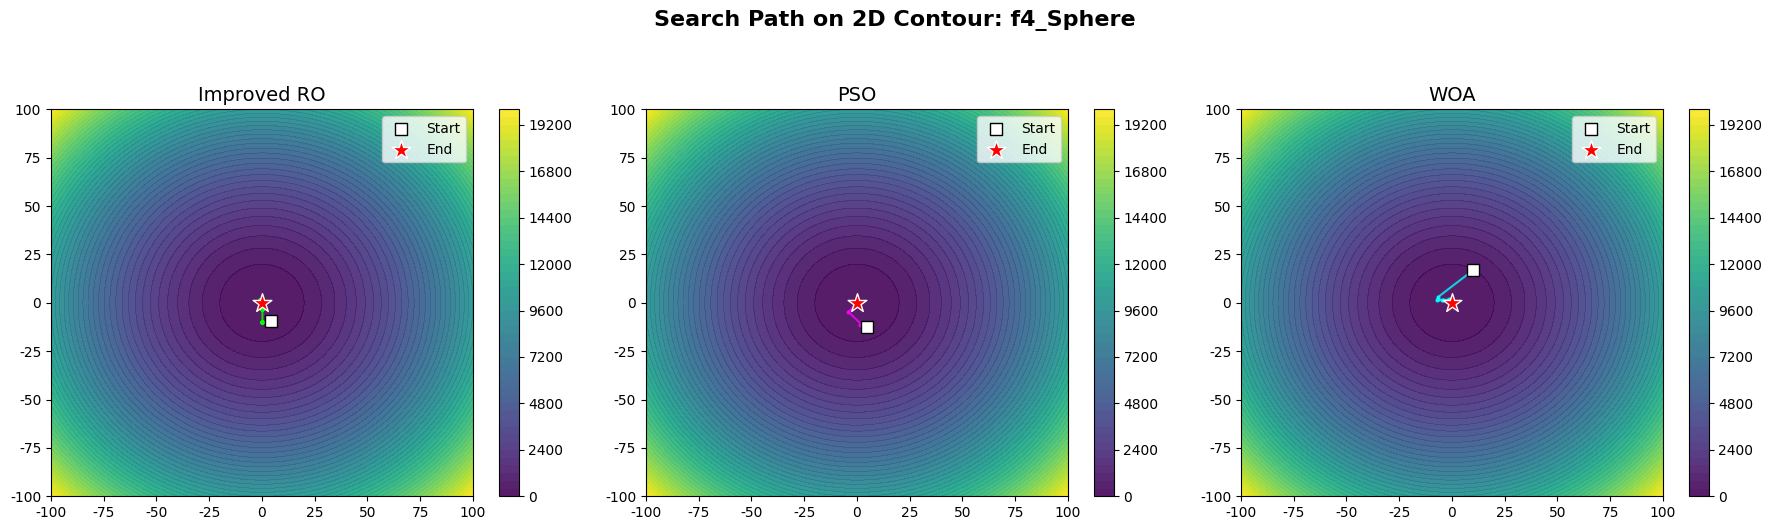


正在處理 f5_Ackley ...


✅ f5_Ackley 繪製完成！已存檔為 path_f5_Ackley.png


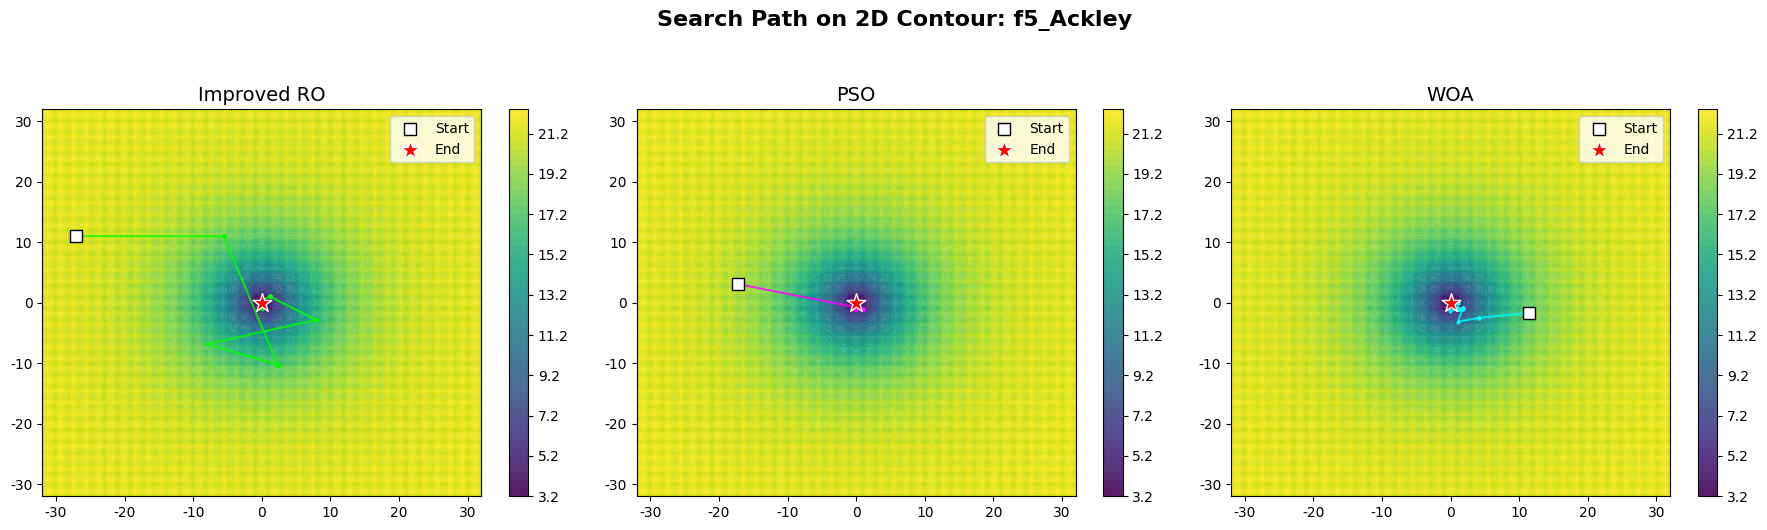


🎉 全部 5 張圖表已順利產生並存檔完成！


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. 定義 f1 到 f5 的 2D 函數
# ==========================================
def f1_rosenbrock(x): return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
def f2_rastrigin(x):  return np.sum(x**2 - 10 * np.cos(2 * np.pi * x) + 10)
def f3_schwefel(x):   return 418.9829 * len(x) - np.sum(x * np.sin(np.sqrt(np.abs(x))))
def f4_sphere(x):     return np.sum(x**2)
def f5_ackley(x):
    D = len(x)
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / D))
    term2 = -np.exp(np.sum(np.cos(2.0 * np.pi * x)) / D)
    return term1 + term2 + 20.0 + np.exp(1)

# ==========================================
# 2. 自動迴圈設定 (函數, 名稱, 繪圖範圍下界, 上界)
# ==========================================
test_functions = [
    # Rosenbrock 在 -5 到 5 比較能看出經典的「香蕉谷」形狀
    {"func": f1_rosenbrock, "name": "f1_Rosenbrock", "lb": -5.0, "ub": 5.0},
    {"func": f2_rastrigin,  "name": "f2_Rastrigin",  "lb": -5.12, "ub": 5.12},
    {"func": f3_schwefel,   "name": "f3_Schwefel",   "lb": -500.0, "ub": 500.0},
    {"func": f4_sphere,     "name": "f4_Sphere",     "lb": -100.0, "ub": 100.0},
    {"func": f5_ackley,     "name": "f5_Ackley",     "lb": -32.0, "ub": 32.0}
]

# ==========================================
# 3. 繪圖與自動存檔共用模組
# ==========================================
def generate_all_paths():
    print("🚀 開始批次產生 5 張 2D 等高線軌跡圖...")

    for test in test_functions:
        func = test["func"]
        name = test["name"]
        lb = test["lb"]
        ub = test["ub"]

        print(f"\n正在處理 {name} ...")

        # 覆蓋全域變數 (若您的演算法內部有使用到 global lb, ub)
        global lb_global, ub_global
        lb_global, ub_global = lb, ub

        # 建立網格
        x1 = np.linspace(lb, ub, 100)
        x2 = np.linspace(lb, ub, 100)
        X1, X2 = np.meshgrid(x1, x2)
        Z = np.zeros_like(X1)
        for i in range(X1.shape[0]):
            for j in range(X1.shape[1]):
                Z[i, j] = func(np.array([X1[i, j], X2[i, j]]))

        # 執行演算法 (D=2)
        pos_ro, _ = run_Improved_RO(2, func)
        pos_pso, _ = run_PSO(2, func)
        pos_woa, _ = run_WOA(2, func)

        pos_ro, pos_pso, pos_woa = np.array(pos_ro), np.array(pos_pso), np.array(pos_woa)

        # 開始繪圖
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"Search Path on 2D Contour: {name}", fontsize=16, fontweight='bold', y=1.05)

        algorithms = [
            ("Improved RO", pos_ro, 'lime'),
            ("PSO", pos_pso, 'magenta'),
            ("WOA", pos_woa, 'cyan')
        ]

        for ax, (algo_name, pos_data, path_color) in zip(axes, algorithms):
            contour = ax.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.9)
            fig.colorbar(contour, ax=ax)

            # 畫軌跡
            ax.plot(pos_data[:, 0], pos_data[:, 1], color=path_color, marker='.', markersize=4, linewidth=1.5, alpha=0.8)
            # 起點 (白方塊)
            ax.scatter(pos_data[0, 0], pos_data[0, 1], color='white', edgecolors='black', marker='s', s=80, zorder=5, label='Start')
            # 終點 (紅星星)
            ax.scatter(pos_data[-1, 0], pos_data[-1, 1], color='red', edgecolors='white', marker='*', s=200, zorder=5, label='End')

            ax.set_title(f"{algo_name}", fontsize=14)
            ax.set_xlim([lb, ub])
            ax.set_ylim([lb, ub])
            ax.legend(loc='upper right')

        plt.tight_layout()

        # 自動存檔成 PNG
        filename = f"path_{name}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"✅ {name} 繪製完成！已存檔為 {filename}")

        plt.show()
        plt.close(fig) # 關閉畫布釋放記憶體

# 執行批次產生
generate_all_paths()
print("\n🎉 全部 5 張圖表已順利產生並存檔完成！")